# Разработка модели машинного обучения для молочного хозяйства «Вольный луг»

**Цель проекта:**

Разработать две прогнозные модели машинного обучения для отбора бурёнок в поголовьею. Первая будет прогнозировать возможный удой коровы (целевой признак Удой). Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока). С помощью модели нужно отобрать коров по двум критериям: средний удой за год — не менее 6000 килограммов; молоко должно быть вкусным.

Данные будут взяты из предоставленных файлов:
* ferma_main.csv содержит данные о стаде фермера на текущий момент
* ferma_dad.csv хранит имя папы каждой коровы в стаде фермера
* cow_buy.csv содержит данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой

Для данных файла cow_buy.csv известно, что:
* Белок и Жирность молока указаны на момент покупки — когда «ЭкоФерма» давала им свой корм.
* Параметры кормления ЭКЕ, Сырой протеин, СПО отсутствуют. Недавно технологи заказчика пересмотрели параметры корма и планируют их внедрить после расширения стада. Именно новые параметры нужно использовать, когда вы будете применять предсказательные модели к бурёнкам «ЭкоФермы». По новой схеме фермер планирует увеличить средние значения ЭКЕ, Сырой протеин, СПО на 5%.

**План работы:**

1. Обзор данных
2. Предобраюотка данных
3. Исследовательский анализ данных
4. Корреляционный анализ данных
5. Обучение модели линейной регрессии для прогнозирования возможного удоя коровы
6. Обучение модели логистической регрессии для оценки вкусности молока
7. Оценка моделей и выводы

In [4]:
!pip install -U scikit-learn -q
!pip install phik -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,
                             mean_squared_error,
                             mean_absolute_error,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             confusion_matrix,
                             precision_recall_curve
                            )
import phik

RANDOM_STATE = 42

## Загрузка данных

In [4]:
df_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', sep=';', decimal=',')
df_main.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [5]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

In [6]:
df_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', sep=';')
df_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [7]:
df_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [8]:
df_cow_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', sep=';', decimal=',')
df_cow_buy.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [9]:
df_cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


В данных нет пропусков. В ferma_main файле 634 коровы, в файле ferma_dad 629 соответствий корова-отец, значит либо у 5 коров отцы неизвестны, либо в ferma_dad есть дубликаты. В файле cow_buy 20 коров, по которым необходим будет прогноз. Параметры кормления ЭКЕ, Сырой протеин, СПО отсутствуют в данных для коров, планируемых к покупке. Названия столбцов для удобства дальнейшей работы будут переименованы.

##  Предобработка данных

In [10]:
df_main.columns = ['id', 'yield', 'energy_feed_unit', 
                   'crude_protein', 'sugar_protein_ratio', 'breed',
                   'pasture_type', 'father_breed', 'fat_content', 'protein',
                   'milk_taste', 'age']
df_main.head()

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [11]:
df_dad.columns = ['id', 'father_name']
df_dad.head()

,id,father_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [12]:
df_cow_buy.columns = ['breed', 'pasture_type', 'father_breed', 'father_name',
       'fat_content', 'protein', 'age']
df_cow_buy.head()

,breed,pasture_type,father_breed,father_name,fat_content,protein,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


Сразу добавлю имя отца в основной датафрейм

In [13]:
df_main = df_main.merge(df_dad, on='id')
df_main.head()

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


In [14]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 634 entries, 0 to 633
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   634 non-null    int64  
 1   yield                634 non-null    int64  
 2   energy_feed_unit     634 non-null    float64
 3   crude_protein        634 non-null    int64  
 4   sugar_protein_ratio  634 non-null    float64
 5   breed                634 non-null    object 
 6   pasture_type         634 non-null    object 
 7   father_breed         634 non-null    object 
 8   fat_content          634 non-null    float64
 9   protein              634 non-null    float64
 10  milk_taste           634 non-null    object 
 11  age                  634 non-null    object 
 12  father_name          634 non-null    object 
dtypes: float64(4), int64(3), object(6)
memory usage: 69.3+ KB


In [15]:
df_main.duplicated().sum()

5

In [16]:
df_main = df_main.drop_duplicates()
df_main.duplicated().sum()

0

In [17]:
df_cow_buy.duplicated().sum()

4

In [18]:
df_cow_buy = df_cow_buy.drop_duplicates()
df_cow_buy.duplicated().sum()

0

In [19]:
df_main['breed'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [20]:
df_cow_buy['breed'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [21]:
df_main['pasture_type'].unique()

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

In [22]:
df_cow_buy['pasture_type'].unique()

array(['холмистое', 'равнинное'], dtype=object)

In [23]:
df_main['pasture_type'] = (df_main['pasture_type'].str.lower()
                           .str.replace('равнинные', 'равнинное', regex=True))
df_main['pasture_type'].unique()

array(['равнинное', 'холмистое'], dtype=object)

In [24]:
df_main['father_breed'].unique()

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

In [25]:
df_cow_buy['father_breed'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [26]:
df_main['father_breed'] = df_main['father_breed'].str.replace('Айдиалл', 'Айдиал', regex=True)
df_main['father_breed'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [27]:
df_main['milk_taste'].unique()

array(['вкусно', 'не вкусно'], dtype=object)

In [28]:
df_main['age'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

In [29]:
df_cow_buy['age'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

In [30]:
df_main['father_name'].unique()

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

In [31]:
df_cow_buy['father_name'].unique()

array(['Геркулес', 'Буйный', 'Барин', 'Соловчик'], dtype=object)

В списке коров фермера было 5 явных дубликатов, которые были удалены. У всех коров фервера есть информация об отцах.

В списке коров на покупку было 4 явных дублликата, осталось 16 коров для выбора. (Сомневаюсь, что данные по коровам абсолютно идентичны, поэтому удалила. Но, возможно, это ошибочное действие)

Были устранены неявные дубликаты в типах пастбищ и породах отцов в списке коров фермера.

Типы данных колонок верные, пропусков нет - это видно по выводу info().

## Исследовательский анализ данных

In [32]:
df_main[['father_breed', 'father_name']].value_counts()

father_breed  father_name
Айдиал        Буйный         215
Соверин       Барин          212
              Соловчик        99
Айдиал        Геркулес        64
              Барин           28
              Соловчик        11
dtype: int64

In [33]:
df_cow_buy[['father_breed', 'father_name']].value_counts()

father_breed  father_name
Айдиал        Буйный         4
Соверин       Буйный         3
              Геркулес       3
Айдиал        Геркулес       2
Соверин       Барин          2
              Соловчик       2
dtype: int64

Для одного и того же имени отца коровы есть соответствие нескольких пород отцов в обоих датафреймах (стадо фермера и коровы на покупку), видимо коров называют одинаково для разных пород. Значит эти 2 колонки не имеют прямой зависимости и необходимо будет проверить точность модели с параметром Имя папы и без.

In [34]:
# добавление в cow_buy значений ЭКЕ, Сырой протеин, СПО как среднее, увеличенное на 5%
df_cow_buy['energy_feed_unit'] = df_main['energy_feed_unit'].mean() * 1.05
df_cow_buy['crude_protein'] = df_main['crude_protein'].mean() * 1.05
df_cow_buy['sugar_protein_ratio'] = df_main['sugar_protein_ratio'].mean() * 1.05
df_cow_buy.head()

,breed,pasture_type,father_breed,father_name,fat_content,protein,age,energy_feed_unit,crude_protein,sugar_protein_ratio
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.271073,2019.532273,0.958772
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.271073,2019.532273,0.958772
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.271073,2019.532273,0.958772
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.271073,2019.532273,0.958772
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.271073,2019.532273,0.958772


In [35]:
df_main.describe()

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,fat_content,protein
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


<Figure size 1440x1440 with 0 Axes>

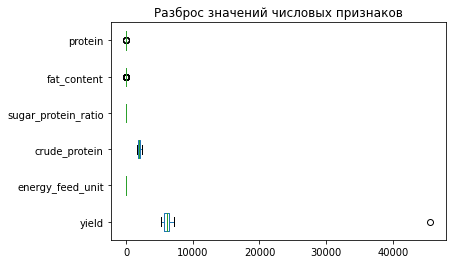

In [36]:
num_col_names = ['yield',
                 'energy_feed_unit',
                 'crude_protein',
                 'sugar_protein_ratio',
                 'fat_content',
                 'protein']

plt.figure(figsize = (20, 20))
df_main[num_col_names].plot(kind='box', vert=False)
plt.title('Разброс значений числовых признаков')
plt.show()

In [37]:
df_main[df_main['yield'] > 10000]

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name
16,17,45616,11.5,1675,0.93,Вис Бик Айдиал,холмистое,Айдиал,3.22,3.076,вкусно,более_2_лет,Буйный


In [38]:
df_main[(df_main['yield'] < 10000)
        & (df_main['breed'] == 'Вис Бик Айдиал')
        & (df_main['age'] == 'более_2_лет')
        & (df_main['father_name'] == 'Буйный')
        & (df_main['pasture_type'] == 'холмистое')
        & (df_main['fat_content'] < 3.24) & (df_main['fat_content'] > 3.20)]

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name
516,517,5650,11.9,2200,0.85,Вис Бик Айдиал,холмистое,Айдиал,3.23,3.079,вкусно,более_2_лет,Буйный


Предположу, что при вводе данных для записи с удоем = 45616 произошла опечатка и в начале добавили лишнюю "4", т.к. похожая корова даёт 5650 кг. Исправлю 45616 на 5616, чтобы не терять запись, и посмотрю как изменится статистика.

In [39]:
df_main[df_main['yield'] < 10000]['yield'].describe()

count     628.000000
mean     6125.968153
std       475.857053
min      5204.000000
25%      5749.750000
50%      6132.500000
75%      6501.000000
max      7222.000000
Name: yield, dtype: float64

In [40]:
df_main.loc[16,'yield'] = 5616
df_main[df_main['yield'] < 10000]['yield'].describe()

count     629.000000
mean     6125.157393
std       475.912622
min      5204.000000
25%      5746.000000
50%      6132.000000
75%      6501.000000
max      7222.000000
Name: yield, dtype: float64

In [41]:
def plot_box_hist(param, param_name):
    #построение ящика с усами
    plt.figure(figsize = (10.5, 2))
    plot_box = plt.boxplot(param, vert=False)
    plt.title(f'Разброс значений параметра {param_name}')
    plt.show()
    #построение гистограммы
    plt.figure(figsize = (10, 6))
    plot_hist = plt.hist(param, bins=30)
    plt.vlines(x=param.mean(), colors='green', ymin=0, ymax=plot_hist[0].max(), label='Среднее')
    plt.vlines(x=param.median(), colors='red', ymin=0, ymax=plot_hist[0].max(), linestyles='--', label='Медиана')
    plt.title(f'Распределение значений параметра {param_name}')
    plt.xlabel(f'{param_name}')
    plt.ylabel('Кол-во коров')
    plt.grid(axis='y')
    plt.legend()
    plt.show()
    return plot_box, plot_hist

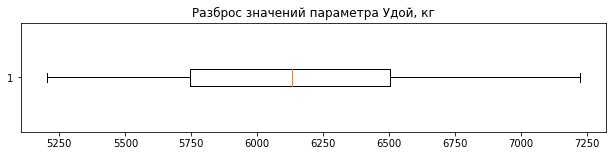

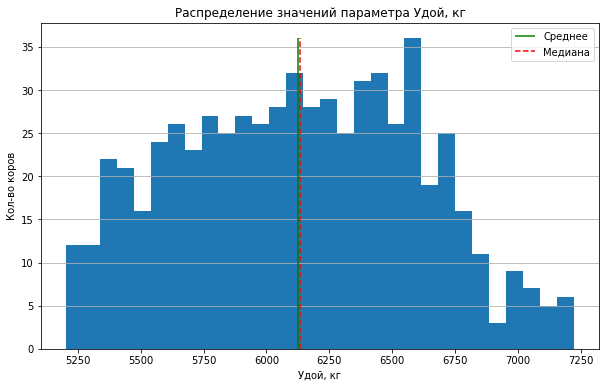

In [42]:
fig = plot_box_hist(df_main['yield'], 'Удой, кг')

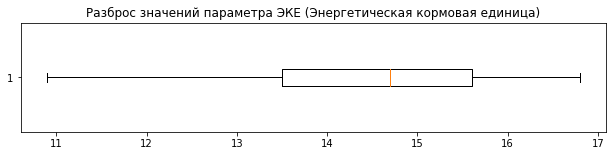

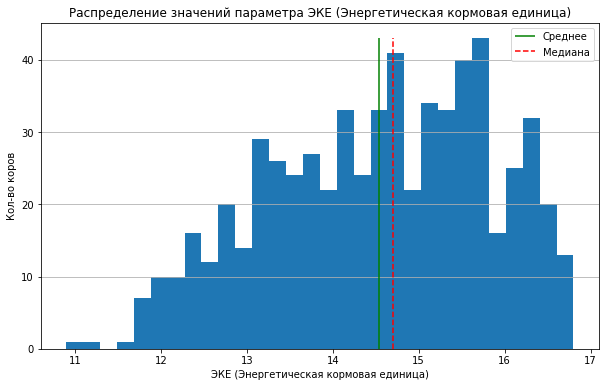

In [43]:
fig = plot_box_hist(df_main['energy_feed_unit'], 'ЭКЕ (Энергетическая кормовая единица)')

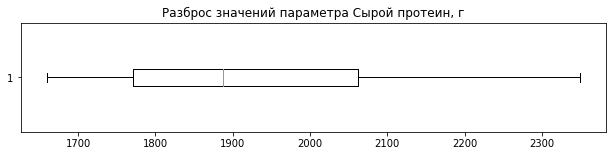

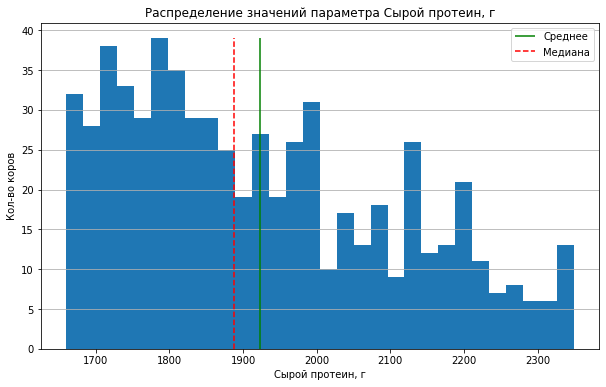

In [44]:
fig = plot_box_hist(df_main['crude_protein'], 'Сырой протеин, г')

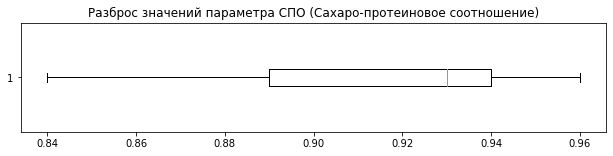

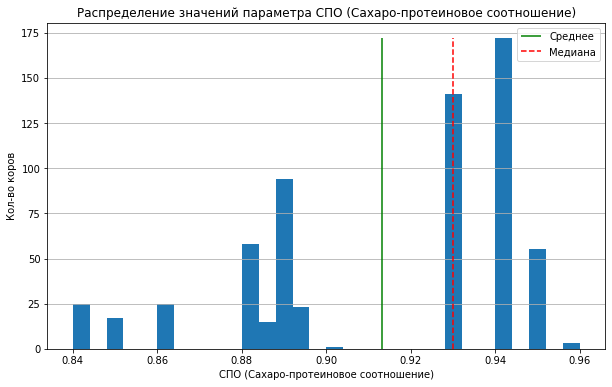

In [45]:
fig = plot_box_hist(df_main['sugar_protein_ratio'], 'СПО (Сахаро-протеиновое соотношение)')

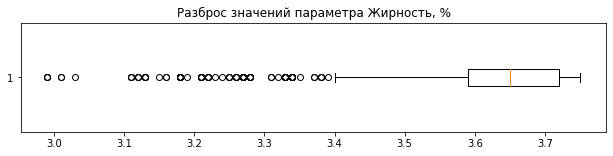

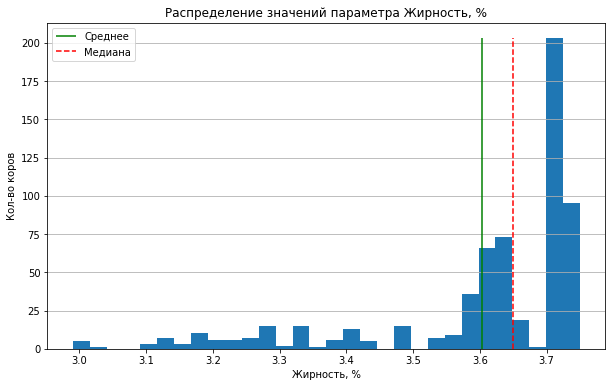

In [46]:
fig = plot_box_hist(df_main['fat_content'], 'Жирность, %')

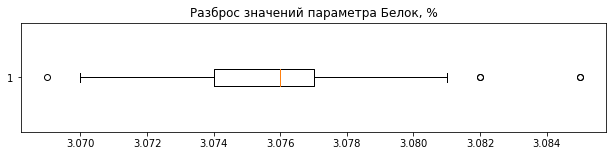

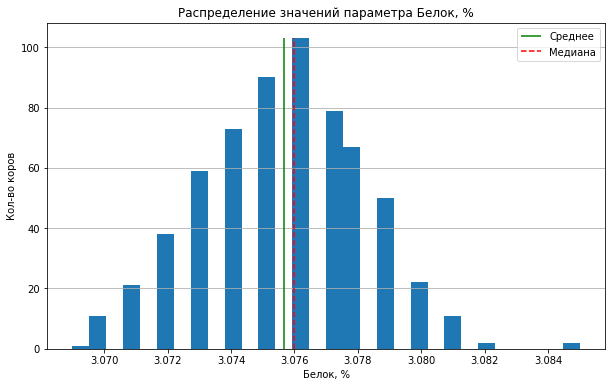

In [47]:
fig = plot_box_hist(df_main['protein'], 'Белок, %')

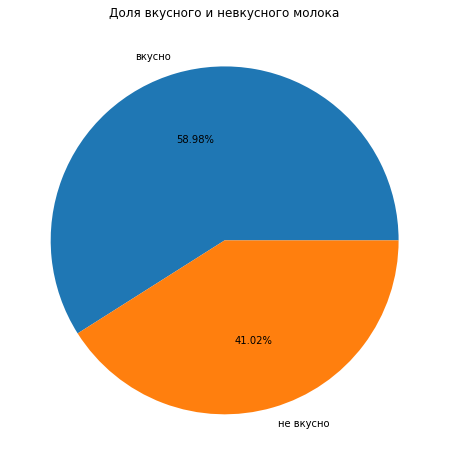

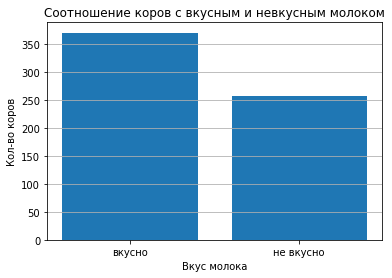

In [48]:
count_milk_taste = df_main['milk_taste'].value_counts()

plt.figure(figsize = (12, 8))

plt.pie(count_milk_taste, labels=count_milk_taste.index, autopct='%1.2f%%')
plt.title('Доля вкусного и невкусного молока')
plt.show()

plt.bar(count_milk_taste.index, count_milk_taste.values)
plt.xlabel('Вкус молока')
plt.ylabel('Кол-во коров')
plt.title('Соотношение коров с вкусным и невкусным молоком')
plt.grid(axis='y')
plt.show()

**В основном датафрейме (данные коров фермера)**

Распределение целевого признака "Удой" приближено к нормальному. Среднее и медиана практически совпадают, есть небольшое смещение влево. Выброс был удалён при помощи корректировки аномального значения.

У параметра "Жирность" нормальное распределение смещено вдево, есть много выбросов слева (единычные значения с малой жирностью), в основном у молока жирность около 3,7%.

У параметра "Белок" нормальное распределение с небольшим смещением влево, есть единичные выбросы: пару значений с большм содержанием белка, одно с маленьким.

У других параметров нет выбросов.

Значения параметра Вкус молока распределены по данным в соотношении 59% вкусного молока, 41% невкусного.Данных должно быть достаточно, чтобы модель научилась определять как вкусное молоко, так и невкусное.

## Корреляционный анализ

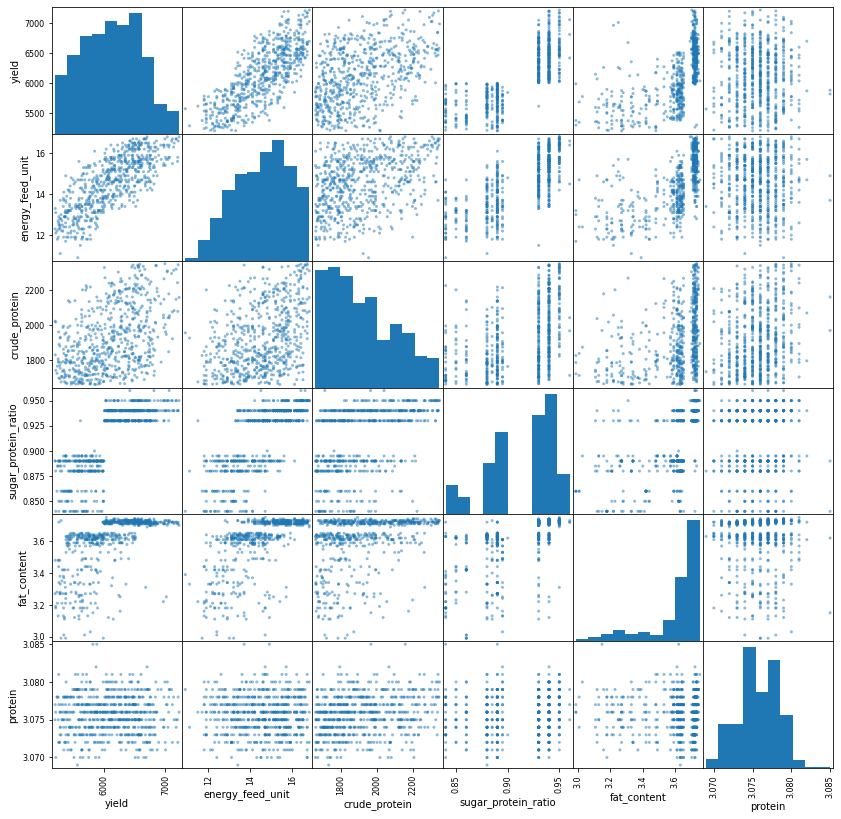

In [49]:
pd.plotting.scatter_matrix(df_main.drop('id', axis=1), figsize = (14, 14))
plt.show()

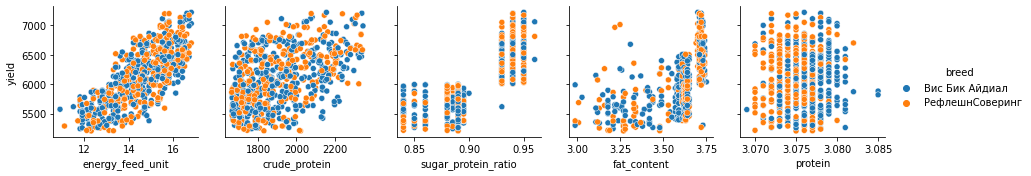

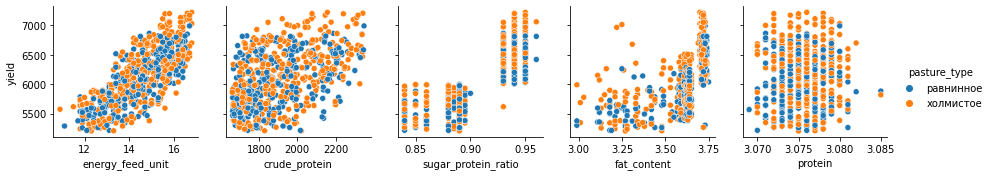

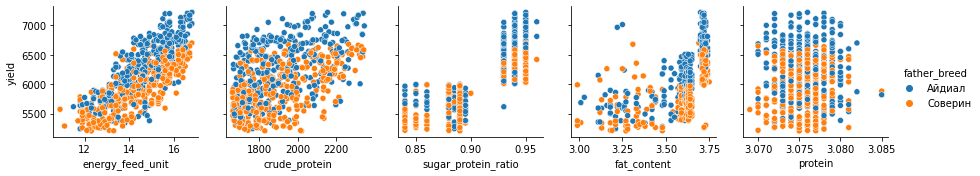

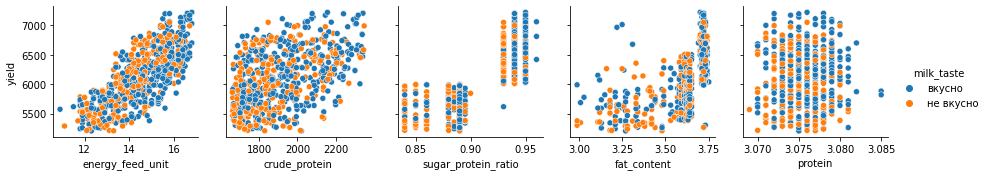

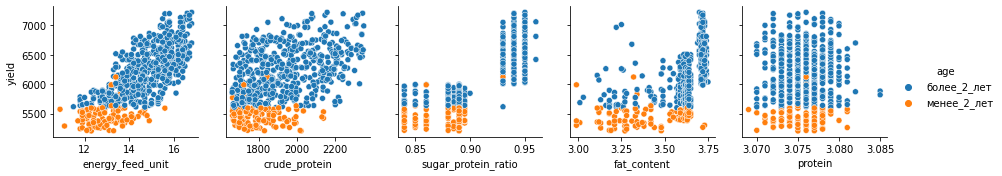

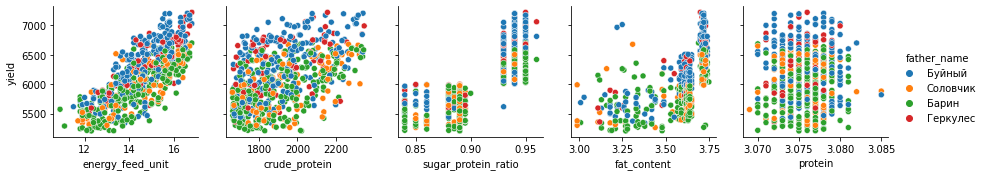

In [50]:
cat = ['breed', 'pasture_type', 'father_breed', 'milk_taste', 'age', 'father_name']
factor = ['energy_feed_unit', 'crude_protein', 'sugar_protein_ratio', 'fat_content', 'protein']

for category in cat:
    g = sns.PairGrid(df_main, hue=category, x_vars=factor, y_vars='yield')
    g.map(sns.scatterplot)
    g.add_legend()

In [51]:
df_main.drop('id', axis=1).phik_matrix()

interval columns not set, guessing: ['yield', 'energy_feed_unit', 'crude_protein', 'sugar_protein_ratio', 'fat_content', 'protein']


,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name
yield,1.000000,0.721540,0.465193,0.660030,0.164966,0.278992,0.518217,0.707379,0.056292,0.174385,0.998102,0.432232
energy_feed_unit,0.721540,1.000000,0.459653,0.589307,0.129219,0.103065,0.166325,0.717846,0.000000,0.271287,0.768438,0.061485
crude_protein,0.465193,0.459653,1.000000,0.386521,0.090792,0.095991,0.000000,0.401195,0.204030,0.174024,0.349587,0.110088
sugar_protein_ratio,0.660030,0.589307,0.386521,1.000000,0.064396,0.158532,0.427779,0.644730,0.074004,0.569538,0.744653,0.410347
breed,0.164966,0.129219,0.090792,0.064396,1.000000,0.211084,0.091673,0.223584,0.361880,0.000000,0.055837,0.382473
pasture_type,0.278992,0.103065,0.095991,0.158532,0.211084,1.000000,0.000000,0.000000,0.101419,0.270583,0.129482,0.233499
father_breed,0.518217,0.166325,0.000000,0.427779,0.091673,0.000000,1.000000,0.000000,0.132270,0.000000,0.356573,0.982965
fat_content,0.707379,0.717846,0.401195,0.644730,0.223584,0.000000,0.000000,1.000000,0.000000,0.198952,0.674410,0.091743
protein,0.056292,0.000000,0.204030,0.074004,0.361880,0.101419,0.132270,0.000000,1.000000,0.145850,0.000000,0.087271
milk_taste,0.174385,0.271287,0.174024,0.569538,0.000000,0.270583,0.000000,0.198952,0.145850,1.000000,0.166869,0.000000


interval columns not set, guessing: ['yield', 'energy_feed_unit', 'crude_protein', 'sugar_protein_ratio', 'fat_content', 'protein']


<AxesSubplot:>

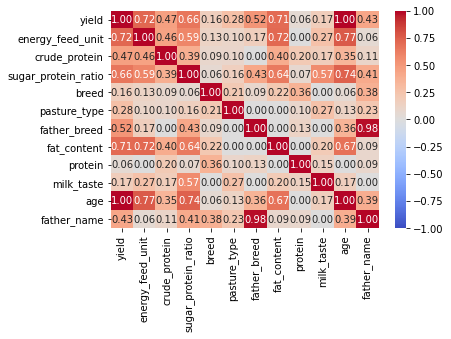

In [52]:
sns.heatmap(df_main.drop('id', axis=1).phik_matrix(), vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='coolwarm')

Есть прямая зависимость удоя от возраста коровы - корреляция признаков равна 1, на графике видно меньшее количество удоя для коров в возрасте менее 2 лет.<br>
Так же по графикам для категориальных параметров видны зависимости удоя:<br>
для пастбища холмистое имеет большие значения удоя, чем равнинное;<br>
для породы отца Айдиал имеет большие значения удоя, чем Соверин.

По графикам и коэффициентам корреляции Пирсона видна линейная зависимость Удоя (целевого признака) от параметра Сырой протеин  и нелинейная зависимость от ЭКЕ и СПО.

Между входными признаками тоже наблюдается линейная зависимость между: 
- ЭКЕ и СПО
- ЭКЕ и Жирность
- СПО и Жирность

Но коэффициент Пирсона меньше 0.9 для них, поэтому удалять зависимые параметры необходимости нет (мультиколлинеарности, которая определяется при значении коэффициента корреляции от 0.9 до 0.95 по модулю, нет).

## Обучение модели линейной регрессии

### Построение модели линейной регрессии на данных датасета farm_main.csv

In [55]:
X = df_main.drop(['id', 'yield', 'fat_content', 'protein', 'milk_taste', 'father_name'], axis=1)
y = df_main['yield']
X.columns

Index(['energy_feed_unit', 'crude_protein', 'sugar_protein_ratio', 'breed',
       'pasture_type', 'father_breed', 'age'],
      dtype='object')

Для входных параметров обучения модели были оставлены ЭКЕ, Сырой протеин, СПО (т.к. параметры корма влияют на Удой), Тип пастбища, Порода, Возраст, Порода папы.

И убраны характеристики молока Жирность, Белок, Вкус молока. Имя папы коровы пока исключено.

In [56]:
# разбиение датафрейма на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE
)

In [57]:
# кодирование категориальных признаков
encoder = OneHotEncoder(drop='first', sparse_output=False)

cat_col_names = ['breed', 'pasture_type', 'father_breed', 'age']

X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])
encoder_col_names = encoder.get_feature_names_out()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

In [58]:
# масштабирование количественных признаков
scaler = StandardScaler()

num_col_names = ['energy_feed_unit', 'crude_protein', 'sugar_protein_ratio']

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

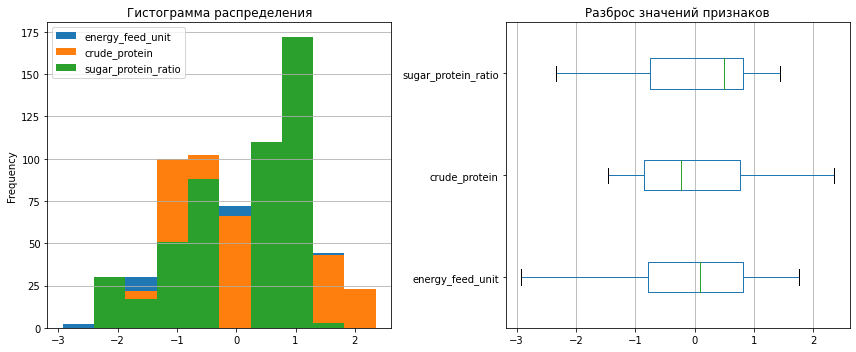

In [59]:
# проверка корректности выполнения масштабирования
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
X_train_scaled[num_col_names].plot(kind='hist', bins=10, ax=axes[0])
axes[0].grid(axis='y')
axes[0].set_title('Гистограмма распределения')
X_train_scaled[num_col_names].plot(kind='box', ax=axes[1], vert=False)
axes[1].grid(axis='x')
axes[1].set_title('Разброс значений признаков')
fig.tight_layout()
plt.show()

Данные отмасштабированы корректно. Значения находятся в промежудке от -3 до 2.5.

In [60]:
# объединение преобразованных категориальных и количественных признаков
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

X_train.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,father_breed_Соверин,age_менее_2_лет,energy_feed_unit,crude_protein,sugar_protein_ratio
0,0.0,0.0,0.0,0.0,0.016344,0.248479,0.814135
1,0.0,0.0,0.0,0.0,0.095707,-1.392310,-1.072496
2,0.0,1.0,0.0,0.0,0.016344,1.124306,0.499697
3,0.0,0.0,0.0,0.0,-1.174092,0.858232,-0.758057
4,1.0,1.0,0.0,0.0,0.571881,-0.671693,0.499697


In [61]:
# создание модели линейной регрессии и получение прогноза
model_lr  = LinearRegression()

model_lr.fit(X_train, y_train)

predictions = model_lr.predict(X_test)

In [62]:
# расчёт R2
r2 = r2_score(y_test ,predictions)
print(f'Коэффициент детерминации = {r2:.2f}')

Коэффициент детерминации = 0.82


Значение коэффициент детерминации (R²) = 0.82, что говорит о том, что модель учитывает 82% факторов, влияющих на результат.

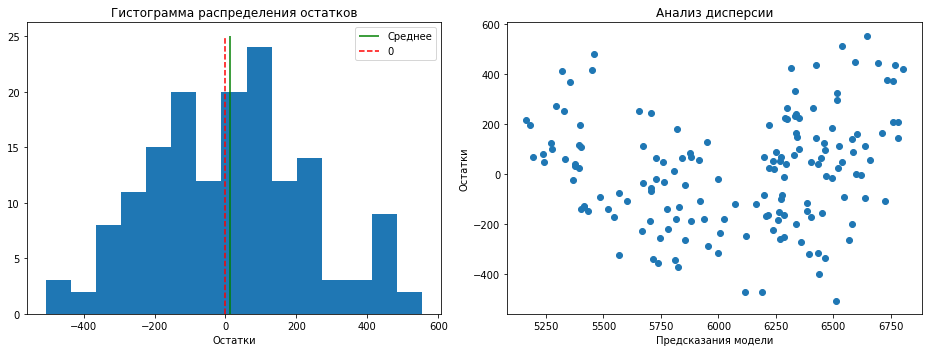

In [63]:
# анализ остатков
residuals = y_test - predictions

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
axes[0].hist(residuals, bins=15)
axes[0].vlines(x=residuals.mean(), colors='green', ymin=0, ymax=25, label='Среднее')
axes[0].vlines(x=0, colors='red', ymin=0, ymax=25, linestyles='--', label='0')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')
axes[0].legend()

axes[1].scatter(predictions, residuals)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
fig.tight_layout()
plt.show()

<AxesSubplot:ylabel='yield'>

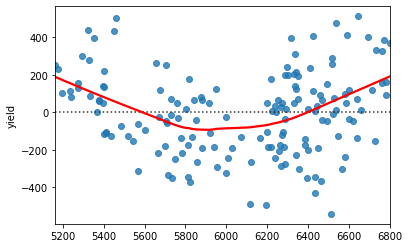

In [64]:
sns.residplot(x=predictions, y=residuals, lowess=True, line_kws=dict(color="r"))

Гистограмма распрееления остатков не имеет хорошо нормализированного распределения, среднее значение смещено вправо относительно нуля. Значит модель недооценивает реальные значения целевого признака, её прогнозы меньше фактических показателей.

Диаграмма рассеяния имеет дугообразный вид. Значит дисперсия неравномерна и это необходимо иправить.

Предсказания модели могут быть непредсказуемыми, значит необходмо либо добавить в модельно новые признаки, либо изменить взаимосвязь входных признаков с целевым.

### Построение модели линейной регрессии с учётом преобразования признаков, нелинейно связанных с целевым признаком

Преобразование данных:

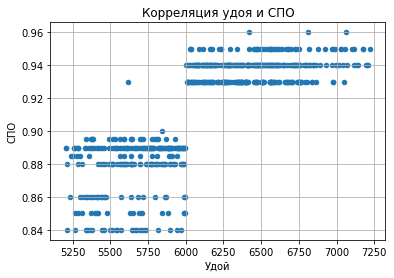

In [65]:
df_main.plot(x = 'yield', y = 'sugar_protein_ratio', kind='scatter')
plt.title('Корреляция удоя и СПО')
plt.xlabel('Удой')
plt.ylabel('СПО')
plt.grid()
plt.show()

In [66]:
def categorize_spr(row):
    if row['sugar_protein_ratio'] > 0.915:
        return 'выше_0.915'
    else:
        return 'ниже_0.915'

In [67]:
# перевод СПО в категориальный признак
df_main['spr_cat'] = df_main.apply(categorize_spr, axis=1)

In [68]:
# возведение ЭКЕ в квадрат
df_main['efu_2'] = df_main['energy_feed_unit'] ** 2

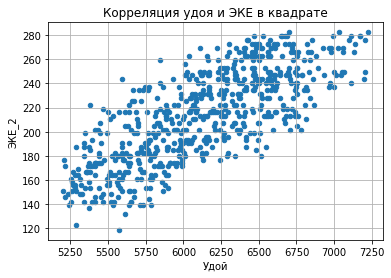

In [69]:
df_main.plot(x = 'yield', y = 'efu_2', kind='scatter')
plt.title('Корреляция удоя и ЭКЕ в квадрате')
plt.xlabel('Удой')
plt.ylabel('ЭКЕ_2')
plt.grid()
plt.show()

Зависимость удоя от ЭКЕ в квадрате линейна

In [70]:
df_main.head()

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name,spr_cat,efu_2
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный,ниже_0.915,201.64
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик,ниже_0.915,163.84
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин,ниже_0.915,196.00
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный,ниже_0.915,153.76
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин,ниже_0.915,163.84


Обучение второй модели:

In [71]:
# из входных данных исклчёны старые значения параметров ЭКЕ и СПО
X2 = df_main.drop(['id', 'yield', 'energy_feed_unit', 'sugar_protein_ratio',
                  'fat_content', 'protein', 'milk_taste', 'father_name'], axis=1)
y2 = df_main['yield']
X2.columns

Index(['crude_protein', 'breed', 'pasture_type', 'father_breed', 'age',
       'spr_cat', 'efu_2'],
      dtype='object')

In [72]:
# разбиение датафрейма на тренировочную и тестовую выборки
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, 
    y2, 
    random_state=RANDOM_STATE
)

In [73]:
# кодирование категориальных признаков
encoder2 = OneHotEncoder(drop='first', sparse_output=False)

cat_col_names2 = ['breed', 'pasture_type', 'father_breed', 'age', 'spr_cat']

X_train_ohe2 = encoder2.fit_transform(X_train2[cat_col_names2])
X_test_ohe2 = encoder2.transform(X_test2[cat_col_names2])
encoder_col_names2 = encoder2.get_feature_names_out()

X_train_ohe2 = pd.DataFrame(X_train_ohe2, columns=encoder_col_names2)
X_test_ohe2 = pd.DataFrame(X_test_ohe2, columns=encoder_col_names2)

In [74]:
# масштабирование количественных признаков
scaler2 = StandardScaler()

num_col_names2 = ['efu_2', 'crude_protein']

X_train_scaled2 = scaler2.fit_transform(X_train2[num_col_names2])
X_test_scaled2 = scaler2.transform(X_test2[num_col_names2])

X_train_scaled2 = pd.DataFrame(X_train_scaled2, columns=num_col_names2)
X_test_scaled2 = pd.DataFrame(X_test_scaled2, columns=num_col_names2)

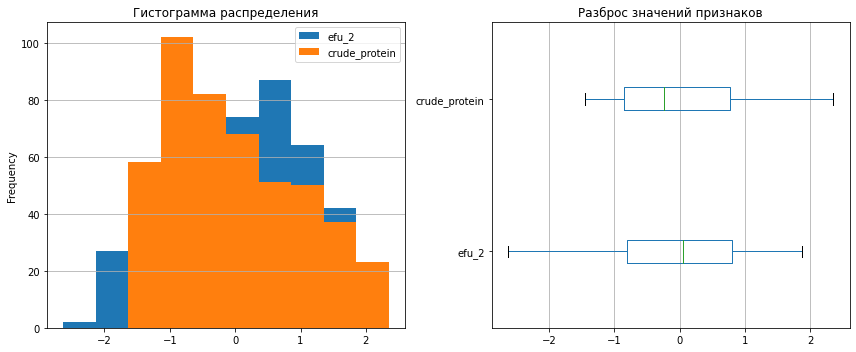

In [75]:
# проверка корректности выполнения масштабирования
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
X_train_scaled2[num_col_names2].plot(kind='hist', bins=10, ax=axes[0])
axes[0].grid(axis='y')
axes[0].set_title('Гистограмма распределения')
X_train_scaled2[num_col_names2].plot(kind='box', ax=axes[1], vert=False)
axes[1].grid(axis='x')
axes[1].set_title('Разброс значений признаков')
fig.tight_layout()
plt.show()

In [76]:
# объединение преобразованных категориальных и количественных признаков
X_train2 = pd.concat([X_train_ohe2, X_train_scaled2], axis=1)
X_test2 = pd.concat([X_test_ohe2, X_test_scaled2], axis=1)

X_train2.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,father_breed_Соверин,age_менее_2_лет,spr_cat_ниже_0.915,efu_2,crude_protein
0,0.0,0.0,0.0,0.0,0.0,-0.027210,0.248479
1,0.0,0.0,0.0,0.0,1.0,0.053583,-1.392310
2,0.0,1.0,0.0,0.0,0.0,-0.027210,1.124306
3,0.0,0.0,0.0,0.0,1.0,-1.172927,0.858232
4,1.0,1.0,0.0,0.0,0.0,0.549923,-0.671693


In [77]:
# создание модели линейной регрессии и получение прогноза
model_lr2  = LinearRegression()

model_lr2.fit(X_train2, y_train2)

predictions2 = model_lr2.predict(X_test2)

In [78]:
# расчёт R2
r2_2 = r2_score(y_test2, predictions2)
print(f'Коэффициент детерминации = {r2_2:.2f}')

Коэффициент детерминации = 0.84


Значение коэффициент детерминации (R²) = 0.84, что говорит о том, что модель учитывает 84% факторов, влияющих на результат.

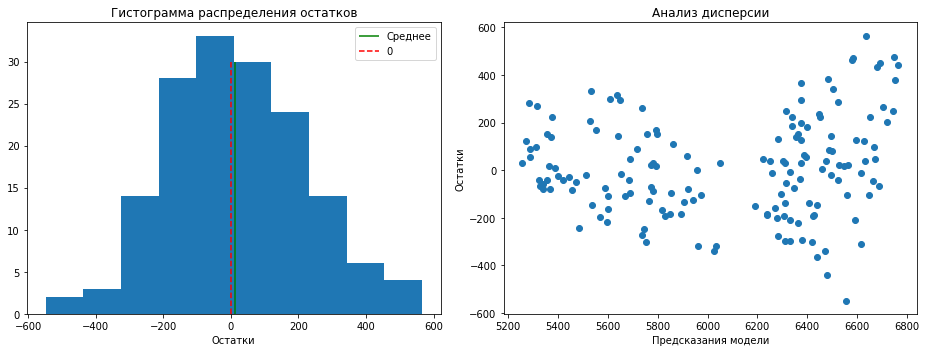

In [79]:
# анализ остатков
residuals2 = y_test2 - predictions2

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
axes[0].hist(residuals2)
axes[0].vlines(x=residuals2.mean(), colors='green', ymin=0, ymax=30, label='Среднее')
axes[0].vlines(x=0, colors='red', ymin=0, ymax=30, linestyles='--', label='0')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')
axes[0].legend()

axes[1].scatter(predictions2, residuals2)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
fig.tight_layout()
plt.show()

Гистограмма распрееления остатков имеет нормальное распределение, среднее имеет небольшое смещение вправо относительно нуля. Значит модель недооценивает реальные значения целевого признака, её прогнозы меньше фактических показателей.

Диаграмма рассеяния показывает неравномерность дисперсии. Модель ошибается неравномерно.

### Построение модели линейной регрессии с учётом нового признака из файла ferma_dad.csv

Построение 3 модели с добавлением параметра Имя папы:

In [80]:
# из входных данных не исклчён параметр father_name - имя папы коровы
X3 = df_main.drop(['id', 'yield', 'energy_feed_unit', 'sugar_protein_ratio',
                  'fat_content', 'protein', 'milk_taste'], axis=1)
y3 = df_main['yield']
X3.columns

Index(['crude_protein', 'breed', 'pasture_type', 'father_breed', 'age',
       'father_name', 'spr_cat', 'efu_2'],
      dtype='object')

In [81]:
# разбиение датафрейма на тренировочную и тестовую выборки
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, 
    y3, 
    random_state=RANDOM_STATE
)

In [82]:
# кодирование категориальных признаков
encoder3 = OneHotEncoder(drop='first', sparse_output=False)

cat_col_names3 = ['breed', 'pasture_type', 'father_breed', 'age', 'father_name', 'spr_cat']

X_train_ohe3 = encoder3.fit_transform(X_train3[cat_col_names3])
X_test_ohe3 = encoder3.transform(X_test3[cat_col_names3])
encoder_col_names3 = encoder3.get_feature_names_out()

X_train_ohe3 = pd.DataFrame(X_train_ohe3, columns=encoder_col_names3)
X_test_ohe3 = pd.DataFrame(X_test_ohe3, columns=encoder_col_names3)

In [83]:
# масштабирование количественных признаков
scaler3 = StandardScaler()

num_col_names3 = ['efu_2', 'crude_protein']

X_train_scaled3 = scaler3.fit_transform(X_train3[num_col_names3])
X_test_scaled3 = scaler3.transform(X_test3[num_col_names3])

X_train_scaled3 = pd.DataFrame(X_train_scaled3, columns=num_col_names3)
X_test_scaled3 = pd.DataFrame(X_test_scaled3, columns=num_col_names3)

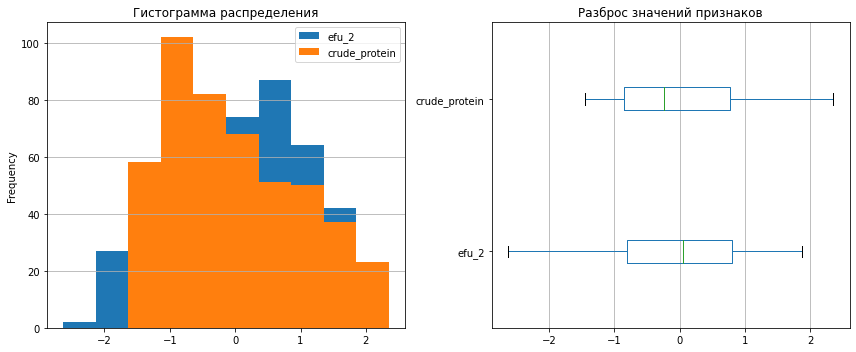

In [84]:
# проверка корректности выполнения масштабирования
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
X_train_scaled3[num_col_names3].plot(kind='hist', bins=10, ax=axes[0])
axes[0].grid(axis='y')
axes[0].set_title('Гистограмма распределения')
X_train_scaled3[num_col_names3].plot(kind='box', ax=axes[1], vert=False)
axes[1].grid(axis='x')
axes[1].set_title('Разброс значений признаков')
fig.tight_layout()
plt.show()

In [85]:
# объединение преобразованных категориальных и количественных признаков
X_train3 = pd.concat([X_train_ohe3, X_train_scaled3], axis=1)
X_test3 = pd.concat([X_test_ohe3, X_test_scaled3], axis=1)

X_train3.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,father_breed_Соверин,age_менее_2_лет,father_name_Буйный,father_name_Геркулес,father_name_Соловчик,spr_cat_ниже_0.915,efu_2,crude_protein
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.027210,0.248479
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.053583,-1.392310
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.027210,1.124306
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-1.172927,0.858232
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.549923,-0.671693


In [86]:
# создание модели линейной регрессии и получение прогноза
model_lr3  = LinearRegression()

model_lr3.fit(X_train3, y_train3)

predictions3 = model_lr3.predict(X_test3)

In [87]:
# расчёт R2
r2_3 = r2_score(y_test3, predictions3)
print(f'Коэффициент детерминации = {r2_3:.2f}')

Коэффициент детерминации = 0.86


Значение коэффициент детерминации (R²) = 0.86, что говорит о том, что модель учитывает 86% факторов, влияющих на результат.

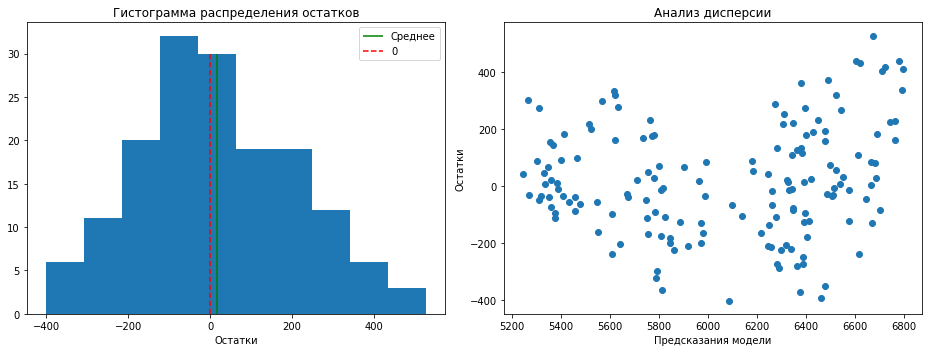

In [88]:
# анализ остатков
residuals3 = y_test3 - predictions3

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
axes[0].hist(residuals3)
axes[0].vlines(x=residuals3.mean(), colors='green', ymin=0, ymax=30, label='Среднее')
axes[0].vlines(x=0, colors='red', ymin=0, ymax=30, linestyles='--', label='0')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')
axes[0].legend()

axes[1].scatter(predictions3, residuals3)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
fig.tight_layout()
plt.show()

<AxesSubplot:ylabel='yield'>

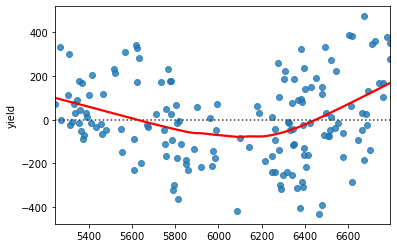

In [89]:
sns.residplot(x=predictions3, y=residuals3, lowess=True, line_kws=dict(color="r"))

Гистограмма распрееления остатков имеет нормальное распределение со смещением вправо относительно нуля. Значит модель недооценивает реальные значения целевого признака, её прогнозы меньше фактических показателей.

Диаграмма рассеяния имеет дугообразный вид. Значит дисперсия неравномерна.

### Сравнение качества трёх моделей линейной регрессии

Последняя 3 модель точнее предсказывает удой - коэффициент детерминации у неё выше - 86%, в отличии от 1 с 82% и 2 с 84%. У 2 и 3 модели нормальное распределение остатков. Дисперсия остатков у всех 3 моделей неравномерна, значит все 3 модели могут ошибаться.

### Расчёт точности каждой модели по трём метрикам: MSE, MAE, RMSE

In [90]:
df_metrics = pd.DataFrame(data = [], columns=['model', 'MAE', 'MSE', 'RMSE'])

In [91]:
def culc_model_metrics(model, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    row = {'model': model, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}
    return row

In [92]:
# добавление метрик первой модели
df_metrics = df_metrics.append(culc_model_metrics('1 модель без преобразований', y_test, predictions), 
                               ignore_index=True)

In [93]:
# добавление метрик второй модели
df_metrics = df_metrics.append(culc_model_metrics('2 модель с преобразованием признаков', y_test2, predictions2),
                               ignore_index=True)

In [94]:
# добавление метрик третей модели
df_metrics = df_metrics.append(culc_model_metrics('3 модель с новым признаком', y_test3, predictions3),
                               ignore_index=True)

In [95]:
df_metrics

,model,MAE,MSE,RMSE
0,1 модель без преобразований,180.797943,49470.596121,222.419864
1,2 модель с преобразованием признаков,164.117416,42729.683759,206.711596
2,3 модель с новым признаком,153.510073,37613.181661,193.941181


Наименьшие значения ошибок имеет последняя 3 модель, в которой учитывалось преобразование входных признаков ЭКЕ и СПО и был добавлен признак Имя папы. Значи точность у неё наибольшая и она будет выбрана для предсказания.

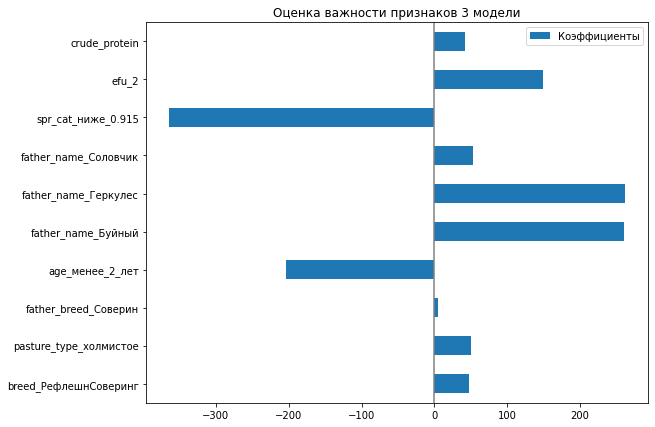

In [96]:
coefs = pd.DataFrame(
    model_lr3.coef_, columns=['Коэффициенты'], index=X_train3.columns
)

coefs.plot(kind="barh", figsize=(9, 7))
plt.title("Оценка важности признаков 3 модели")
plt.axvline(x=0, color=".5")

In [97]:
# Рассчитываем доверительный интервал с помощью `stats.t.ppf()`:  
t_value = stats.t.ppf(0.95, len(predictions3))  # Табличное значение из распределения Стьюдента для 95% доверительного интервала и 20 степеней свободы  

# доверительный интервал:  
conf_interval = (predictions3.mean() - t_value * (mean_squared_error(y_test3, predictions3))**0.5,\
                 predictions3.mean() + t_value * (mean_squared_error(y_test3, predictions3))**0.5)  # Нижняя и верхняя границы доверительного интервала  
conf_interval

(5748.41385349591, 6390.186506412841)

In [98]:
interval = (predictions3.mean() - (mean_squared_error(y_test3, predictions3))**0.5,\
            predictions3.mean() + (mean_squared_error(y_test3, predictions3))**0.5)  
interval

(5875.3589990228, 6263.241360885951)

In [99]:
# Определите доверительный интервал прогноза лучшей модели
np.quantile(predictions3, 0.05), np.quantile(predictions3, 0.95)

(5334.580890703348, 6703.795415910877)

### Применение лучшей по качеству и по точности модели к данным из датасета cow_buy.csv

In [100]:
df_cow_buy['spr_cat'] = df_cow_buy.apply(categorize_spr, axis=1)
df_cow_buy['efu_2'] = df_cow_buy['energy_feed_unit'] ** 2
df_cow_buy

,breed,pasture_type,father_breed,father_name,fat_content,protein,age,energy_feed_unit,crude_protein,sugar_protein_ratio,spr_cat,efu_2
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
10,Вис Бик Айдиал,холмистое,Соверин,Соловчик,3.73,3.055,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675
11,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675


In [101]:
#кодирование категориальных параметров
cow_buy_ohe = encoder3.transform(df_cow_buy[cat_col_names3])
#encoder_col_names3 = encoder3.get_feature_names()
cow_buy_ohe = pd.DataFrame(cow_buy_ohe, columns=encoder_col_names3)

In [102]:
# масштабирование данных
cow_buy_scaled = scaler3.transform(df_cow_buy[num_col_names3])
cow_buy_scaled = pd.DataFrame(cow_buy_scaled, columns=num_col_names3)

In [103]:
# объединение преобразованных категориальных и количественных признаков
cow_buy = pd.concat([cow_buy_ohe, cow_buy_scaled], axis=1)
cow_buy.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,father_breed_Соверин,age_менее_2_лет,father_name_Буйный,father_name_Геркулес,father_name_Соловчик,spr_cat_ниже_0.915,efu_2,crude_protein
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.525538,0.539677
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.525538,0.539677
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.525538,0.539677
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.525538,0.539677
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.525538,0.539677


In [104]:
cow_buy_predictions = model_lr3.predict(cow_buy)
cow_buy_predictions

array([6548.89475757, 6296.35613848, 6288.07544563, 6593.39285874,
       6542.74061297, 6346.14416978, 6500.50777631, 6389.24122091,
       6344.87421422, 6550.2958076 , 6548.89475757, 6087.43298734,
       6593.39285874, 6344.87421422, 6346.14416978, 6500.50777631])

In [105]:
df_cow_buy['yield_predicted'] = cow_buy_predictions
df_cow_buy

,breed,pasture_type,father_breed,father_name,fat_content,protein,age,energy_feed_unit,crude_protein,sugar_protein_ratio,spr_cat,efu_2,yield_predicted
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6548.894758
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6296.356138
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6288.075446
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6593.392859
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6542.740613
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6346.144170
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6500.507776
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6389.241221
10,Вис Бик Айдиал,холмистое,Соверин,Соловчик,3.73,3.055,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6344.874214
11,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6550.295808


Модель предсказала годовой удой для всех коров из файла cow_buy больше 6000 кг в год, т.е. все коровы соответствуют требованию фермера.

## Обучение модели логистической регрессии

### Обучение модели

Выбор параметров для отпределения вкуса молока. 

Не беру параметры:
- ЭКЕ (Энергетическая кормовая единица), т.к. влияет на насыщенность корма, но не на вкус молока
- Сырой протеин, т.к. влияет на жирность молока, беру только жирность в качестве входного параметра
- данные об отце, т.к. не должно быть зависимости, беру породу самой коровы
- Удой, т.к. количество не должно влиять на качество

Беру, т.к. должны влиять на вкус молока:
- Жирность и Белок
- СПО (Сахаро-протеиновое соотношение), т.к. неверное соотношение портит вкус молока
- Породу и возраст
- Пастбище

In [106]:
# перевод вкуса молока в 0 и 1 для удобства дальнейшей работы
def set_01_values(row):
    if row['milk_taste'] == 'вкусно':
        return 1
    else:
        return 0

def set_str_values(row):
    if row['milk_taste_predicted'] == 1:
        return 'вкусно'
    else:
        return 'не вкусно'
    
df_main['milk_taste_01'] = df_main.apply(set_01_values, axis=1)
df_main.head(3)

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,father_breed,fat_content,protein,milk_taste,age,father_name,spr_cat,efu_2,milk_taste_01
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный,ниже_0.915,201.64,1
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик,ниже_0.915,163.84,1
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин,ниже_0.915,196.00,0


In [107]:
X_lr = df_main[['sugar_protein_ratio',
                'fat_content',
                'protein',
                'breed', 
                'pasture_type',
                'age']]
y_lr = df_main['milk_taste_01']

In [108]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
X_lr,
y_lr,
random_state=RANDOM_STATE
)

In [109]:
# кодирование категориальных признаков
encoder_lr = OneHotEncoder(drop='first', sparse_output=False)

cat_col_names_lr = ['breed', 'pasture_type', 'age']

X_train_ohe_lr = encoder_lr.fit_transform(X_train_lr[cat_col_names_lr])
X_test_ohe_lr = encoder_lr.transform(X_test_lr[cat_col_names_lr])
encoder_col_names_lr = encoder_lr.get_feature_names_out()

X_train_ohe_lr = pd.DataFrame(X_train_ohe_lr, columns=encoder_col_names_lr)
X_test_ohe_lr = pd.DataFrame(X_test_ohe_lr, columns=encoder_col_names_lr)

In [110]:
# масштабирование количественных признаков
scaler_lr = StandardScaler()

num_col_names_lr = ['sugar_protein_ratio', 'fat_content', 'protein']

X_train_scaled_lr = scaler_lr.fit_transform(X_train_lr[num_col_names_lr])
X_test_scaled_lr = scaler_lr.transform(X_test_lr[num_col_names_lr])

X_train_scaled_lr = pd.DataFrame(X_train_scaled_lr, columns=num_col_names_lr)
X_test_scaled_lr = pd.DataFrame(X_test_scaled_lr, columns=num_col_names_lr)

In [111]:
# объединение преобразованных категориальных и количественных признаков
X_train_lr = pd.concat([X_train_ohe_lr, X_train_scaled_lr], axis=1)
X_test_lr = pd.concat([X_test_ohe_lr, X_test_scaled_lr], axis=1)

X_train_lr.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,age_менее_2_лет,sugar_protein_ratio,fat_content,protein
0,0.0,0.0,0.0,0.814135,0.199205,1.666305
1,0.0,0.0,0.0,-1.072496,-2.618012,1.283462
2,0.0,1.0,0.0,0.499697,0.076717,0.517774
3,0.0,0.0,0.0,-0.758057,0.199205,0.134930
4,1.0,1.0,0.0,0.499697,0.566668,-2.162133


In [112]:
# создание модели логистической регрессии и получение прогноза
clf = LogisticRegression()
clf = clf.fit(X_train_lr, y_train_lr)
y_pred_lr = clf.predict(X_test_lr)

In [113]:
accuracy = accuracy_score(y_test_lr, y_pred_lr)
recall_average = recall_score(y_test_lr, y_pred_lr) #, average="binary", pos_label='вкусно')
precision_average = precision_score(y_test_lr, y_pred_lr) #, average="binary", pos_label='вкусно')

print('accuracy: ', round(accuracy ,3))
print('recall: ', round(recall_average ,3))
print('precision: ', round(precision_average,3))

accuracy:  0.639
recall:  0.773
precision:  0.682


Качество модели по метрике accuracy = 64%. Т.е. в 64% случаях модель не ошибается.<br>
Качество модели по метрике recall = 77%. Т.е. в 77% случаях модель не ошибается при определении вкусного молока.<br>
Качество модели по метрике precision = 68%. Т.е. в 68% случаях модель не ошибается при определении невкусного молока.

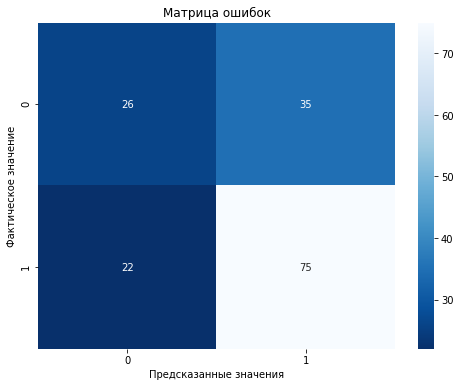

In [114]:
# матрица ошибок
plt.figure(figsize = (8, 6))
cm = confusion_matrix(y_test_lr, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.title('Матрица ошибок')
plt.ylabel('Фактическое значение')
plt.xlabel('Предсказанные значения')
plt.show()

### Анализ модели

Для модели необходимо точное определение вкусного молока, т.е. ложно-положительных предсказаний должно быть как можно меньше. Для этого нужно увеличить precision.

In [115]:
# настройка порога
y_proba_lr = clf.predict_proba(X_test_lr)[:,1]
data = pd.DataFrame(zip(y_test_lr, y_proba_lr),
                    columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)
data.head()

,y_valid,y_proba
22,1,0.775231
17,1,0.763433
5,1,0.754191
56,1,0.743762
95,1,0.743762


In [116]:
thresholds = [round(i,2) for i in np.linspace(0.1, 1, num=10, endpoint=False)]
thresholds

[0.1, 0.19, 0.28, 0.37, 0.46, 0.55, 0.64, 0.73, 0.82, 0.91]

In [117]:
columns = []

for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred_'+str(i)] = data['y_proba'].apply(lambda x : 1 if x>=i else 0)

data.sample(10)

,y_valid,y_proba,y_pred_0.1,y_pred_0.19,y_pred_0.28,y_pred_0.37,y_pred_0.46,y_pred_0.55,y_pred_0.64,y_pred_0.73,y_pred_0.82,y_pred_0.91
156,1,0.532224,1,1,1,1,1,0,0,0,0,0
113,1,0.629493,1,1,1,1,1,1,0,0,0,0
115,1,0.395868,1,1,1,1,0,0,0,0,0,0
120,1,0.464448,1,1,1,1,1,0,0,0,0,0
28,0,0.558014,1,1,1,1,1,1,0,0,0,0
126,0,0.320305,1,1,1,0,0,0,0,0,0,0
104,1,0.415809,1,1,1,1,0,0,0,0,0,0
116,0,0.719835,1,1,1,1,1,1,1,0,0,0
9,0,0.279041,1,1,0,0,0,0,0,0,0,0
76,1,0.530936,1,1,1,1,1,0,0,0,0,0


Порог классификации необходимо сдвинуть с 0,5 на 0,7 для уменьшения ложно-положительных ошибок

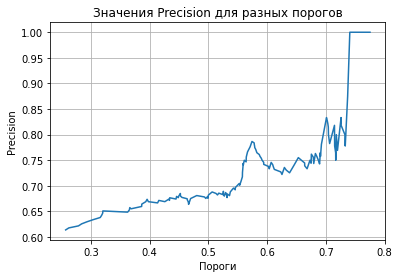

In [118]:
precision, recall, thresh = precision_recall_curve(y_true=y_test_lr, y_score=y_proba_lr)
fig, ax = plt.subplots()
ax.plot(thresh, precision[:-1])
ax.set_title('Значения Precision для разных порогов')
ax.set_ylabel('Precision')
ax.set_xlabel('Пороги')
ax.grid()
plt.show()

### Применение модели

In [119]:
# кодирование категориальных признаков
cow_buy_ohe_lr = encoder_lr.transform(df_cow_buy[cat_col_names_lr])
#encoder_col_names_lr = encoder_lr.get_feature_names()
cow_buy_ohe_lr = pd.DataFrame(cow_buy_ohe_lr, columns=encoder_col_names_lr)

# масштабирование количественных признаков
cow_buy_scaled_lr = scaler_lr.transform(df_cow_buy[num_col_names_lr])
cow_buy_scaled_lr = pd.DataFrame(cow_buy_scaled_lr, columns=num_col_names_lr)

# объединение преобразованных категориальных и количественных признаков
cow_buy_lr = pd.concat([cow_buy_ohe_lr, cow_buy_scaled_lr], axis=1)

cow_buy_lr.head()

,breed_РефлешнСоверинг,pasture_type_холмистое,age_менее_2_лет,sugar_protein_ratio,fat_content,protein
0,0.0,1.0,0.0,1.404395,-0.168258,0.134930
1,0.0,0.0,1.0,1.404395,-0.413233,2.049149
2,1.0,0.0,0.0,1.404395,-0.107014,-0.630758
3,1.0,1.0,0.0,1.404395,-1.270647,-5.607727
4,1.0,0.0,0.0,1.404395,0.199205,-0.630758


In [120]:
#THRESHOLD = 0.7
#class_distrib = {0:THRESHOLD, 1:THRESHOLD}
#clf_2 = LogisticRegression(class_weight = class_distrib)
#clf_2 = clf_2.fit(X_train_lr, y_train_lr)

In [121]:
custom_threshold = 0.7
cow_buy_proba_lr = clf.predict_proba(cow_buy_lr)
cow_buy_proba_lr

array([[0.23671711, 0.76328289],
       [0.27757017, 0.72242983],
       [0.40017184, 0.59982816],
       [0.45526387, 0.54473613],
       [0.40095174, 0.59904826],
       [0.71265808, 0.28734192],
       [0.32068603, 0.67931397],
       [0.19202027, 0.80797973],
       [0.55521042, 0.44478958],
       [0.4182872 , 0.5817128 ],
       [0.69234623, 0.30765377],
       [0.23368919, 0.76631081],
       [0.39107208, 0.60892792],
       [0.20447502, 0.79552498],
       [0.71451684, 0.28548316],
       [0.47324987, 0.52675013]])

In [122]:
preds = (cow_buy_proba_lr[:,1] >= custom_threshold).astype(int)
preds

array([1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0])

In [123]:
df_cow_buy['milk_taste_predicted'] = preds
df_cow_buy['milk_taste_predicted'] = df_cow_buy.apply(set_str_values, axis=1)
df_cow_buy

,breed,pasture_type,father_breed,father_name,fat_content,protein,age,energy_feed_unit,crude_protein,sugar_protein_ratio,spr_cat,efu_2,yield_predicted,milk_taste_predicted
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6548.894758,вкусно
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6296.356138,вкусно
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6288.075446,не вкусно
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6593.392859,не вкусно
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6542.740613,не вкусно
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6346.144170,не вкусно
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6500.507776,не вкусно
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6389.241221,вкусно
10,Вис Бик Айдиал,холмистое,Соверин,Соловчик,3.73,3.055,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6344.874214,не вкусно
11,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6550.295808,не вкусно


## Итоговые выводы

В ходе работы над проектом:
- была выполнена обработка данных, убраны явные и неявные дубликаты
- был проведён исследовательский анаиз данных, полученный от фермера
- был проведён анализ зависимости данных для более корректного обучения модели
- в рамках работы по созданию модели линейной регрессии было:
    - построена модель по первоначальным данным с анализом её эффективности (по R², распределению остатков и анализу дисперсии остатков)
    - выполнено преобразование признаков, которые были нелинейно связаны с целевым, и построена вторая модель на основе обновлённых данных, проведён анализ её эффективности (по R², распределению остатков и анализу дисперсии остатков)
    - добавлен дополнительный признак (имя отца) и построена 3 модель с учётом этого параметра, проведён анализ её эффективности (по R², распределению остатков и анализу дисперсии остатков)
    - выполнен расчёт метрик (R², MAE, MSE, RMSE) по 3 моделям и выбрана наилучшая модель для выполнения предсказания
    - рассчитан удой для коров из предоставленного файла cow_buy (для всех коров предсказанное значения удоя более 6000 кг в год)
- в рамках работы по созданию модели логистической регрессии было:
    - выбраны признаки для обучения модели
    - построена модель по выбранным параметрм
    - проведён анализ работы модели
    - подобран порог, улучшающий качество предсказания по целевому признаку со значение "вкусное"
    - получено прдсказание модели с учётом выбранного порога

Коровы, для которых спрогнозирован удой более 6000 килограммов в год и вкусное молоко, отсортированные в порядке уменьшения предказанного удоя:

In [124]:
df_cow_buy[(df_cow_buy['yield_predicted'] > 6000) & (df_cow_buy['milk_taste_predicted'] == 'вкусно')].sort_values('yield_predicted', ascending=False)

,breed,pasture_type,father_breed,father_name,fat_content,protein,age,energy_feed_unit,crude_protein,sugar_protein_ratio,spr_cat,efu_2,yield_predicted,milk_taste_predicted
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6548.894758,вкусно
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6389.241221,вкусно
16,Вис Бик Айдиал,холмистое,Соверин,Соловчик,3.73,3.079,более_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6344.874214,вкусно
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6296.356138,вкусно
13,Вис Бик Айдиал,холмистое,Соверин,Барин,3.42,3.075,менее_2_лет,15.271073,2019.532273,0.958772,выше_0.915,233.205675,6087.432987,вкусно


Средняя ошибка модели, определяющей удой, 193 кг, поэтому лучше отдать предпочтение коровам с предсказанным удоем 6288 и выше. Т.к. вкус молока является условным параметром и сложно определить какие именно факторы на него влияют и точность модели, предсказывающей вкусность 83%, то лучше молоко коровы перед покупкой попробовать. 

### Ответьте на вопросы: 
- Какие способы улучшения качества регрессионной модели вы использовали в этой задаче?
> возведение значений параметра в квадрат для появления линейной зависимости между входным признаком и целевым; приведение числовых значений к категориальным, т.к. между входным и целевым признаком не было линейной зависимости; добавление нового признака во входные данные
- Возможно ли ещё улучшить результаты регрессионной модели? Если можно, то как? Если нет, то почему?
> возможно, если есть ещё какие-то признаки, которые влияют на удой, но не были предоставлены, которые имеют линейную зависимость с величиной удоя. Но возможно таких признаков нет и нужно пробовать другую модель, нелинейную.
- Какие метрики моделей классификации, в том числе логистической регрессии, важны при анализе рисков или экономических расчётов?
> accuracy, recall, precision